In [1]:
from joblib import Parallel, delayed
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import pickle
import sys
from contextlib import suppress, redirect_stdout, redirect_stderr

In [2]:
%load_ext autoreload
%autoreload 2
import helper_functions as fx
import trade_functions as tf
import parse_histdata

In [3]:
parse_histdata.clean_data()

Replacing 1 rows with non-positive close prices with 0
Replacing 1 rows with close prices above 3.1232 with 1.5616
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 1.8446 with 0.9223
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 296.406 with 148.203
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 4.0662 with 2.0331
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 3.5356 with 1.7678

In [3]:
file_path = '/Volumes/SEAGATE/FX_data/FX_histdata/'
fx_pairs = ["EURUSD", "EURGBP", "USDJPY", "GBPUSD", "USDCHF", "USDCAD", "AUDUSD", "NZDUSD", "EURJPY", "GBPJPY", "EURCHF", "AUDJPY", "EURAUD", "GBPAUD"]
intervals = ['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']

In [5]:
timeline_df = parse_histdata.timeline_info(fx_pairs)
display(timeline_df)

,Pair,Start,End,Missing Minutes,Max Missing Minutes,Percentage Missing
0,EURUSD,2001-01,2023-12,305633,15547.0,2.527773
1,EURGBP,2002-03,2023-12,388973,5882.0,3.388823
2,USDJPY,2000-05,2023-12,376567,15548.0,3.036179
3,GBPUSD,2000-05,2023-12,345669,15546.0,2.787056
4,USDCHF,2000-05,2023-12,337047,19091.0,2.717530
5,USDCAD,2000-06,2023-12,505296,216573.0,4.080162
6,AUDUSD,2000-06,2023-12,417251,79473.0,3.366455
7,NZDUSD,2005-08,2023-12,301344,5883.0,3.117335
8,EURJPY,2002-03,2023-12,129127,5882.0,1.124984
9,GBPJPY,2002-05,2023-12,93632,13059.0,0.821788


### Test period : 2018-2023 (walk-forward validation)
### Training period : start - 2010 ()

* Initial Training period has only been set upto 2010, due to computational and time constraints.
* Rolling calibration will be from 2011.

Plan to use LSTM to explore pair trading between currency pairs


In [ ]:
fx.create_interval_datasets(fx_pairs, intervals, file_path)

Creating 1T datasets for all pairs
Processing EURUSD for 1T interval
Creating 1T dataset for EURUSD
Processing EURGBP for 1T interval
Creating 1T dataset for EURGBP
Processing USDJPY for 1T interval
Creating 1T dataset for USDJPY
Processing GBPUSD for 1T interval
Creating 1T dataset for GBPUSD
Processing USDCHF for 1T interval
Creating 1T dataset for USDCHF
Processing USDCAD for 1T interval
Creating 1T dataset for USDCAD
Processing AUDUSD for 1T interval
Creating 1T dataset for AUDUSD
Processing NZDUSD for 1T interval
Creating 1T dataset for NZDUSD
Processing EURJPY for 1T interval
Creating 1T dataset for EURJPY
Processing GBPJPY for 1T interval
Creating 1T dataset for GBPJPY
Processing EURCHF for 1T interval
Creating 1T dataset for EURCHF
Processing AUDJPY for 1T interval
Creating 1T dataset for AUDJPY
Processing EURAUD for 1T interval
Creating 1T dataset for EURAUD
Processing GBPAUD for 1T interval
Creating 1T dataset for GBPAUD
Creating 5T datasets for all pairs
Processing EURUSD fo

In the code above, following interpretation has been used:
For Datetime t, the data represents the period from t-1 (included) up till t (not included)
Hence while resampling, (label=right, closed=right) have been used.

In [13]:
fx.calculate_returns(fx_pairs, intervals, file_path)

Calculating returns for 1T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 5T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 10T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 15T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 30T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 1H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 3H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/1

These results suggest atleast a linear Granger-causal relationship between the various columns.

Note: 
* For 'Close', the pacf spike at lag1 and sudden drop and slow trail-off of acf indicates non-stationarity.
* For 'Return' and 'logReturn', the acf and pacf spike at lag1 indicate an ARMA(1,1) process.

In [47]:
spread_lag = spread.shift(1)
spread_ret = spread - spread_lag
spread_lag = spread_lag[1:]
spread_ret = spread_ret[1:]

half_life = -np.log(2) / fx.get_beta_lr(spread_lag, spread_ret)
print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")

Estimated Half-Life of Mean Reversion: 0.77 periods


* Initial Test period for static hedge ratios and half-lives: 2011-01-01 to 2015-12-31

In [ ]:
# Need to run this on Colab Pro (prolly A100)
res = fx.initial_granger_cointegration(fx_pairs, intervals, file_path, end_td=pd.Timedelta(days=252*5), end_max=pd.Timestamp('2010-12-31'), n_jobs=2)
with open('./temp/granger_coint_results.pkl', 'wb') as f:
    pickle.dump(res, f)

Running initial Granger cointegration tests for interval 1T...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:257: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Sign

Skipping EURUSD and USDJPY at interval 1T due to low correlation (-0.06)


[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   41.1s
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:257: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:285: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1 = forward_fill_df(df1).resample(common_freq, label='right', closed='right').agg({
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:29

Skipping EURUSD and GBPUSD at interval 1T due to low correlation (0.09)


/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:257: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:285: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1 = forward_fill_df(df1).resample(common_freq, label='right', closed='right').agg({
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:291: FutureWarning: 'T' is deprecated and will be removed in a 

KeyboardInterrupt: 

In [13]:
print(res)

{('AUDJPY', 'EURAUD', '6H'): 2006-01-31    2.218256e-08
2006-02-21    1.790068e-08
2006-03-14    1.841939e-08
2006-04-04    1.918772e-08
2006-04-25    2.166241e-08
                  ...     
2012-10-02    9.575926e-03
2012-10-23    1.274417e-02
2012-11-13    1.795049e-02
2012-12-04    1.921399e-02
2012-12-25    2.763536e-02
Name: pval, Length: 121, dtype: float64, ('AUDJPY', 'EURAUD', '1D'): 2006-02-01    0.000003
2006-02-22    0.000004
2006-03-15    0.000003
2006-04-05    0.000003
2006-04-26    0.000004
                ...   
2012-10-03    0.003317
2012-10-24    0.008345
2012-11-14    0.010780
2012-12-05    0.014286
2012-12-26    0.024514
Name: pval, Length: 121, dtype: float64}


<Axes: title={'center': "Rolling Engle-Granger p-values for 'AUDJPY' & 'EURAUD' - 1D"}>

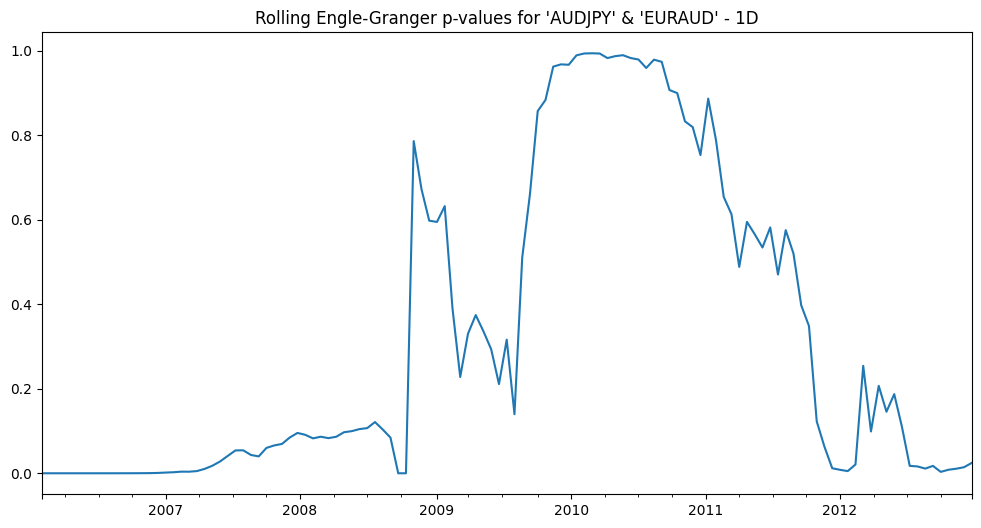

In [15]:
res[('AUDJPY', 'EURAUD', '1D')].plot(title=f"Rolling Engle-Granger p-values for 'AUDJPY' & 'EURAUD' - 1D", figsize=(12, 6))

ADF p-value: 0.6723
Estimated Half-Life of Mean Reversion: 54506.57 periods
Hedge Ratio: 0.3541


NameError: name 'spread_ret' is not defined

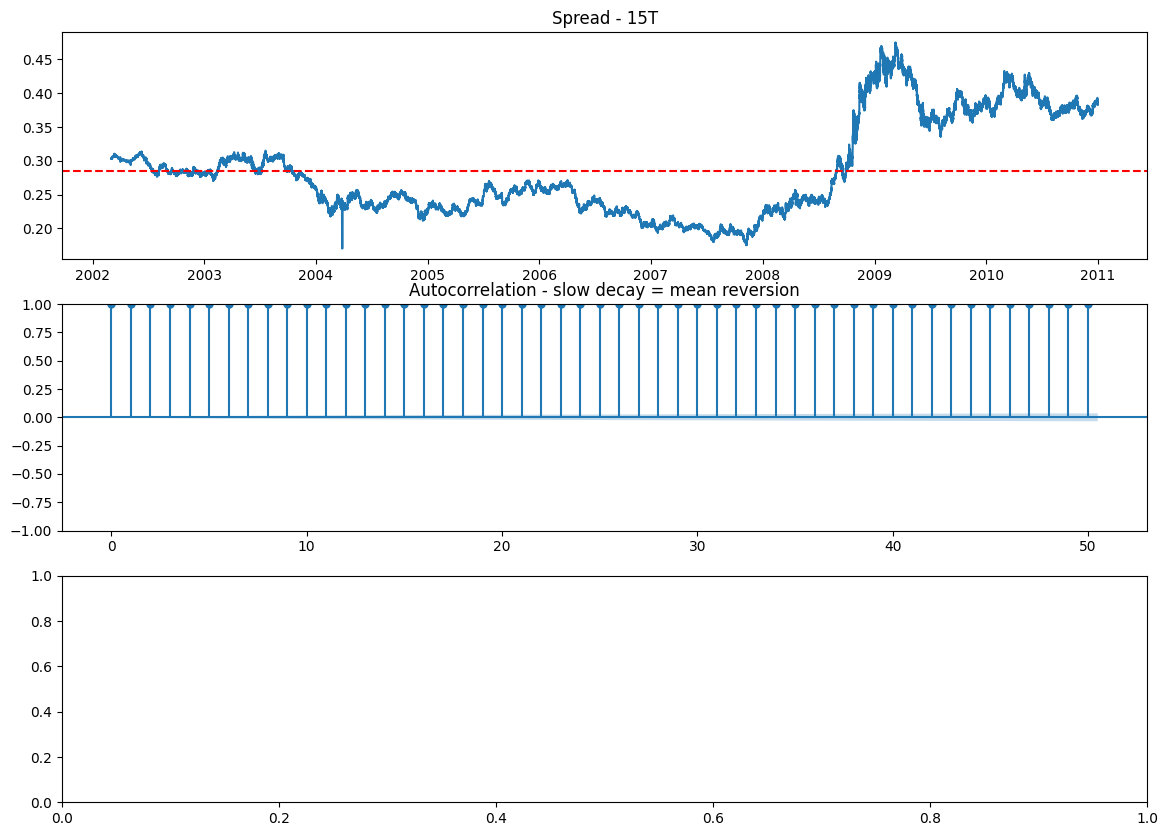

In [ ]:
# 1. Visual check - do spreads mean revert?
pair1 = eurusd_train
pair2 = eurgbp_train
def plot_spread_diagnostic(pair1, pair2, interval):

    hedge_ratio = fx.get_beta_lr(pair1['Close'], pair2['Close'])
    spread = pair2['Close'] - hedge_ratio * pair1['Close']

    # 3. The SPREAD should be stationary I(0)
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(spread.dropna(), maxlag=50)
    print(f"ADF p-value: {adf_result[1]:.4f}")
    # If p < 0.05, spread is stationary → cointegrated

    # 4. Calculate half-life on the STATIONARY spread
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread - spread_lag
    spread_ret = spread_diff.dropna()
    beta = fx.get_beta_lr(spread_lag.dropna(), spread_ret.dropna())
    half_life = -np.log(2) / beta
    print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")
    print(f"Hedge Ratio: {hedge_ratio:.4f}")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Raw spread
    axes[0].plot(spread.index, spread)
    axes[0].set_title(f'Spread - {interval}')
    axes[0].axhline(spread.mean(), color='red', linestyle='--')
    
    # ACF plot - should decay slowly if mean reverting
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(spread.dropna(), lags=50, ax=axes[1])
    axes[1].set_title('Autocorrelation - slow decay = mean reversion')
    
    # Regression
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(spread_lag.values.reshape(-1,1), spread_ret.values)
    beta = model.coef_[0]
    
    axes[2].scatter(spread_lag, spread_ret, alpha=0.1, s=1)
    axes[2].plot(spread_lag, model.predict(spread_lag.values.reshape(-1,1)), 
                 'r-', label=f'beta={beta:.6f}')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[2].set_xlabel('Spread(t-1)')
    axes[2].set_ylabel('Spread(t) - Spread(t-1)')
    axes[2].set_title('Mean Reversion Check - negative slope = reversion')
    axes[2].legend()
    
    plt.tight_layout()
    
    if beta >= 0:
        print(f"BETA POSITIVE ({beta:.6f}) - NO MEAN REVERSION")
    else:
        half_life = -np.log(2) / beta
        print(f"Beta: {beta:.6f}, Half-life: {half_life:.2f} bars")
    
    return beta, half_life if beta < 0 else np.inf


beta, half_life = plot_spread_diagnostic(pair1, 
                                    pair2, 
                                    interval)
plt.show()

In [9]:
print(intervals)

['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']


In [ ]:
# Get Hurst exponent for log(price1/price2) of all pairs at same intervals for first 5 years
# Filter combos with H < 0.5
# Code max lags threshold for Granger cointegration, based on interval
# Get Granger cointegration results for spread of filtered combos for first 5 years
# 

In [14]:
hurst_res = fx.wrap_hurst(fx_pairs, intervals, file_path)

Computing Hurst exponent for 1T interval...
EURUSD-EURGBP: H = 0.5083
EURUSD-USDJPY: H = 0.4849
EURUSD-GBPUSD: H = 0.4724
EURUSD-USDCHF: H = 0.4850
EURUSD-USDCAD: H = 0.4823
EURUSD-AUDUSD: H = 0.4704
EURUSD-NZDUSD: H = 0.4885
EURUSD-EURJPY: H = 0.4965
EURUSD-GBPJPY: H = 0.5076
EURUSD-EURCHF: H = 0.5165
EURUSD-AUDJPY: H = 0.3124
EURUSD-EURAUD: H = 0.5312
EURUSD-GBPAUD: H = 0.5077
EURGBP-USDJPY: H = 0.5057
EURGBP-GBPUSD: H = 0.4885
EURGBP-USDCHF: H = 0.5175
EURGBP-USDCAD: H = 0.5135
EURGBP-AUDUSD: H = 0.4966
EURGBP-NZDUSD: H = 0.5137
EURGBP-EURJPY: H = 0.4693
EURGBP-GBPJPY: H = 0.4732
EURGBP-EURCHF: H = 0.4797
EURGBP-AUDJPY: H = 0.3248
EURGBP-EURAUD: H = 0.4821
EURGBP-GBPAUD: H = 0.5076
USDJPY-GBPUSD: H = 0.4900
USDJPY-USDCHF: H = 0.5244
USDJPY-USDCAD: H = 0.5042
USDJPY-AUDUSD: H = 0.4798
USDJPY-NZDUSD: H = 0.4910
USDJPY-EURJPY: H = 0.5107
USDJPY-GBPJPY: H = 0.5359
USDJPY-EURCHF: H = 0.4890
USDJPY-AUDJPY: H = 0.3595
USDJPY-EURAUD: H = 0.4737
USDJPY-GBPAUD: H = 0.4796
GBPUSD-USDCHF: H = 0

In [22]:
hurst_df = pd.DataFrame(
        [[[] for _ in fx_pairs] for _ in fx_pairs],
        index=fx_pairs,
        columns=fx_pairs
    )
for interval in intervals:
    interval_data = hurst_res.get(interval, {})
    
    for (pair1, pair2), H in interval_data.items():
        hurst_df.loc[pair1, pair2].append(np.round(H, 3))
        hurst_df.loc[pair2, pair1].append(np.round(H, 3))

for pair in fx_pairs:
    hurst_df.loc[pair, pair] = []
display(hurst_df)

,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,[],"[0.508, 0.526, 0.539, 0.532, 0.545, 0.557, 0.5...","[0.485, 0.492, 0.479, 0.551, 0.552, 0.553, 0.5...","[0.472, 0.472, 0.459, 0.504, 0.491, 0.494, 0.4...","[0.485, 0.491, 0.477, 0.55, 0.551, 0.555, 0.56...","[0.482, 0.488, 0.471, 0.559, 0.553, 0.553, 0.5...","[0.47, 0.468, 0.461, 0.472, 0.468, 0.476, 0.45...","[0.489, 0.498, 0.528, 0.526, 0.533, 0.541, 0.5...","[0.496, 0.485, 0.524, 0.519, 0.529, 0.532, 0.5...","[0.508, 0.515, 0.518, 0.519, 0.526, 0.526, 0.5...","[0.516, 0.507, 0.518, 0.506, 0.517, 0.532, 0.5...","[0.312, 0.288, 0.302, 0.279, 0.294, 0.347, 0.3...","[0.531, 0.537, 0.543, 0.55, 0.557, 0.556, 0.56...","[0.508, 0.51, 0.514, 0.51, 0.515, 0.527, 0.517..."
EURGBP,"[0.508, 0.526, 0.539, 0.532, 0.545, 0.557, 0.5...",[],"[0.506, 0.513, 0.523, 0.517, 0.53, 0.533, 0.53...","[0.489, 0.492, 0.496, 0.495, 0.49, 0.509, 0.49...","[0.517, 0.532, 0.54, 0.535, 0.548, 0.549, 0.56...","[0.514, 0.529, 0.536, 0.534, 0.545, 0.548, 0.5...","[0.497, 0.506, 0.516, 0.51, 0.517, 0.527, 0.53...","[0.514, 0.513, 0.55, 0.542, 0.551, 0.565, 0.57...","[0.469, 0.464, 0.459, 0.462, 0.455, 0.462, 0.4...","[0.473, 0.47, 0.467, 0.466, 0.463, 0.466, 0.44...","[0.48, 0.473, 0.477, 0.467, 0.472, 0.474, 0.45...","[0.325, 0.306, 0.315, 0.303, 0.314, 0.369, 0.3...","[0.482, 0.489, 0.489, 0.491, 0.495, 0.498, 0.4...","[0.508, 0.517, 0.519, 0.524, 0.524, 0.531, 0.5..."
USDJPY,"[0.485, 0.492, 0.479, 0.551, 0.552, 0.553, 0.5...","[0.506, 0.513, 0.523, 0.517, 0.53, 0.533, 0.53...",[],"[0.49, 0.523, 0.527, 0.526, 0.528, 0.537, 0.54...","[0.524, 0.536, 0.54, 0.543, 0.552, 0.544, 0.57...","[0.504, 0.504, 0.509, 0.503, 0.511, 0.516, 0.5...","[0.48, 0.484, 0.472, 0.48, 0.46, 0.469, 0.446,...","[0.491, 0.501, 0.513, 0.527, 0.521, 0.527, 0.5...","[0.511, 0.5, 0.573, 0.568, 0.586, 0.59, 0.612,...","[0.536, 0.535, 0.546, 0.537, 0.557, 0.559, 0.5...","[0.489, 0.482, 0.488, 0.479, 0.49, 0.504, 0.47...","[0.359, 0.338, 0.352, 0.337, 0.352, 0.424, 0.3...","[0.474, 0.48, 0.479, 0.475, 0.471, 0.482, 0.48...","[0.48, 0.479, 0.478, 0.479, 0.473, 0.474, 0.45..."
GBPUSD,"[0.472, 0.472, 0.459, 0.504, 0.491, 0.494, 0.4...","[0.489, 0.492, 0.496, 0.495, 0.49, 0.509, 0.49...","[0.49, 0.523, 0.527, 0.526, 0.528, 0.537, 0.54...",[],"[0.508, 0.529, 0.52, 0.532, 0.519, 0.509, 0.52...","[0.5, 0.53, 0.525, 0.525, 0.526, 0.519, 0.54, ...","[0.479, 0.471, 0.465, 0.471, 0.458, 0.467, 0.4...","[0.492, 0.497, 0.492, 0.5, 0.497, 0.504, 0.489...","[0.487, 0.474, 0.498, 0.497, 0.499, 0.51, 0.50...","[0.504, 0.507, 0.51, 0.508, 0.515, 0.517, 0.51...","[0.503, 0.49, 0.499, 0.491, 0.496, 0.513, 0.49...","[0.326, 0.306, 0.319, 0.3, 0.317, 0.374, 0.33,...","[0.515, 0.522, 0.522, 0.529, 0.532, 0.527, 0.5...","[0.518, 0.517, 0.527, 0.518, 0.53, 0.54, 0.541..."
USDCHF,"[0.485, 0.491, 0.477, 0.55, 0.551, 0.555, 0.56...","[0.517, 0.532, 0.54, 0.535, 0.548, 0.549, 0.56...","[0.524, 0.536, 0.54, 0.543, 0.552, 0.544, 0.57...","[0.508, 0.529, 0.52, 0.532, 0.519, 0.509, 0.52...",[],"[0.51, 0.52, 0.519, 0.528, 0.524, 0.529, 0.536...","[0.485, 0.493, 0.479, 0.49, 0.471, 0.475, 0.46...","[0.5, 0.51, 0.527, 0.535, 0.528, 0.541, 0.541,...","[0.5, 0.493, 0.549, 0.548, 0.559, 0.556, 0.571...","[0.52, 0.521, 0.527, 0.526, 0.534, 0.534, 0.53...","[0.513, 0.502, 0.514, 0.501, 0.514, 0.537, 0.5...","[0.35, 0.329, 0.344, 0.329, 0.342, 0.409, 0.35...","[0.484, 0.491, 0.485, 0.488, 0.482, 0.487, 0.4...","[0.484, 0.496, 0.488, 0.502, 0.488, 0.485, 0.4..."
USDCAD,"[0.482, 0.488, 0.471, 0.559, 0.553, 0.553, 0.5...","[0.514, 0.529, 0.536, 0.534, 0.545, 0.548, 0.5...","[0.504, 0.504, 0.509, 0.503, 0.511, 0.516, 0.5...","[0.5, 0.53, 0.525, 0.525, 0.526, 0.519, 0.54, ...","[0.51, 0.52, 0.519, 0.528, 0.524, 0.529, 0.536...",[],"[0.489, 0.491, 0.478, 0.486, 0.471, 0.478, 0.4...","[0.51, 0.508, 0.537, 0.532, 0.537, 0.552, 0.55...","[0.496, 0.488, 0.546, 0.545, 0.558, 0.558, 0.5...","[0.513, 0.513, 0.523, 0.52, 0.529, 0.533, 0.

In [28]:
# Count combos with H < 0.5 at each interval
combos_filtered = []
for interval in intervals:
    interval_data = hurst_res.get(interval, {})
    count_H_lt_0_5 = sum(1 for H in interval_data.values() if H < 0.50)
    for (pair1, pair2), H in interval_data.items():
        if H < 0.50:
            combos_filtered.append((pair1, pair2, interval))
    print(f"Interval: {interval}, Combos with H < 0.5: {count_H_lt_0_5}")

Interval: 1T, Combos with H < 0.5: 55
Interval: 5T, Combos with H < 0.5: 56
Interval: 10T, Combos with H < 0.5: 43
Interval: 15T, Combos with H < 0.5: 40
Interval: 30T, Combos with H < 0.5: 38
Interval: 1H, Combos with H < 0.5: 30
Interval: 3H, Combos with H < 0.5: 38
Interval: 6H, Combos with H < 0.5: 31
Interval: 1D, Combos with H < 0.5: 40


In [ ]:
with open('./temp/hurst_results.pkl', 'wb') as f:
    pickle.dump(hurst_df, f)

In [4]:
with open('./temp/hurst_results.pkl', 'rb') as f:
    hurst_df = pickle.load(f)

In [5]:
display(hurst_df.head())

,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,[],"[0.508, 0.526, 0.539, 0.532, 0.545, 0.557, 0.5...","[0.485, 0.492, 0.479, 0.551, 0.552, 0.553, 0.5...","[0.472, 0.472, 0.459, 0.504, 0.491, 0.494, 0.4...","[0.485, 0.491, 0.477, 0.55, 0.551, 0.555, 0.56...","[0.482, 0.488, 0.471, 0.559, 0.553, 0.553, 0.5...","[0.47, 0.468, 0.461, 0.472, 0.468, 0.476, 0.45...","[0.489, 0.498, 0.528, 0.526, 0.533, 0.541, 0.5...","[0.496, 0.485, 0.524, 0.519, 0.529, 0.532, 0.5...","[0.508, 0.515, 0.518, 0.519, 0.526, 0.526, 0.5...","[0.516, 0.507, 0.518, 0.506, 0.517, 0.532, 0.5...","[0.312, 0.288, 0.302, 0.279, 0.294, 0.347, 0.3...","[0.531, 0.537, 0.543, 0.55, 0.557, 0.556, 0.56...","[0.508, 0.51, 0.514, 0.51, 0.515, 0.527, 0.517..."
EURGBP,"[0.508, 0.526, 0.539, 0.532, 0.545, 0.557, 0.5...",[],"[0.506, 0.513, 0.523, 0.517, 0.53, 0.533, 0.53...","[0.489, 0.492, 0.496, 0.495, 0.49, 0.509, 0.49...","[0.517, 0.532, 0.54, 0.535, 0.548, 0.549, 0.56...","[0.514, 0.529, 0.536, 0.534, 0.545, 0.548, 0.5...","[0.497, 0.506, 0.516, 0.51, 0.517, 0.527, 0.53...","[0.514, 0.513, 0.55, 0.542, 0.551, 0.565, 0.57...","[0.469, 0.464, 0.459, 0.462, 0.455, 0.462, 0.4...","[0.473, 0.47, 0.467, 0.466, 0.463, 0.466, 0.44...","[0.48, 0.473, 0.477, 0.467, 0.472, 0.474, 0.45...","[0.325, 0.306, 0.315, 0.303, 0.314, 0.369, 0.3...","[0.482, 0.489, 0.489, 0.491, 0.495, 0.498, 0.4...","[0.508, 0.517, 0.519, 0.524, 0.524, 0.531, 0.5..."
USDJPY,"[0.485, 0.492, 0.479, 0.551, 0.552, 0.553, 0.5...","[0.506, 0.513, 0.523, 0.517, 0.53, 0.533, 0.53...",[],"[0.49, 0.523, 0.527, 0.526, 0.528, 0.537, 0.54...","[0.524, 0.536, 0.54, 0.543, 0.552, 0.544, 0.57...","[0.504, 0.504, 0.509, 0.503, 0.511, 0.516, 0.5...","[0.48, 0.484, 0.472, 0.48, 0.46, 0.469, 0.446,...","[0.491, 0.501, 0.513, 0.527, 0.521, 0.527, 0.5...","[0.511, 0.5, 0.573, 0.568, 0.586, 0.59, 0.612,...","[0.536, 0.535, 0.546, 0.537, 0.557, 0.559, 0.5...","[0.489, 0.482, 0.488, 0.479, 0.49, 0.504, 0.47...","[0.359, 0.338, 0.352, 0.337, 0.352, 0.424, 0.3...","[0.474, 0.48, 0.479, 0.475, 0.471, 0.482, 0.48...","[0.48, 0.479, 0.478, 0.479, 0.473, 0.474, 0.45..."
GBPUSD,"[0.472, 0.472, 0.459, 0.504, 0.491, 0.494, 0.4...","[0.489, 0.492, 0.496, 0.495, 0.49, 0.509, 0.49...","[0.49, 0.523, 0.527, 0.526, 0.528, 0.537, 0.54...",[],"[0.508, 0.529, 0.52, 0.532, 0.519, 0.509, 0.52...","[0.5, 0.53, 0.525, 0.525, 0.526, 0.519, 0.54, ...","[0.479, 0.471, 0.465, 0.471, 0.458, 0.467, 0.4...","[0.492, 0.497, 0.492, 0.5, 0.497, 0.504, 0.489...","[0.487, 0.474, 0.498, 0.497, 0.499, 0.51, 0.50...","[0.504, 0.507, 0.51, 0.508, 0.515, 0.517, 0.51...","[0.503, 0.49, 0.499, 0.491, 0.496, 0.513, 0.49...","[0.326, 0.306, 0.319, 0.3, 0.317, 0.374, 0.33,...","[0.515, 0.522, 0.522, 0.529, 0.532, 0.527, 0.5...","[0.518, 0.517, 0.527, 0.518, 0.53, 0.54, 0.541..."
USDCHF,"[0.485, 0.491, 0.477, 0.55, 0.551, 0.555, 0.56...","[0.517, 0.532, 0.54, 0.535, 0.548, 0.549, 0.56...","[0.524, 0.536, 0.54, 0.543, 0.552, 0.544, 0.57...","[0.508, 0.529, 0.52, 0.532, 0.519, 0.509, 0.52...",[],"[0.51, 0.52, 0.519, 0.528, 0.524, 0.529, 0.536...","[0.485, 0.493, 0.479, 0.49, 0.471, 0.475, 0.46...","[0.5, 0.51, 0.527, 0.535, 0.528, 0.541, 0.541,...","[0.5, 0.493, 0.549, 0.548, 0.559, 0.556, 0.571...","[0.52, 0.521, 0.527, 0.526, 0.534, 0.534, 0.53...","[0.513, 0.502, 0.514, 0.501, 0.514, 0.537, 0.5...","[0.35, 0.329, 0.344, 0.329, 0.342, 0.409, 0.35...","[0.484, 0.491, 0.485, 0.488, 0.482, 0.487, 0.4...","[0.484, 0.496, 0.488, 0.502, 0.488, 0.485, 0.4..."


In [6]:
# Convert dataframe of lists to list of tuples (pair1, pair2, interval) where value < 0.5
combos_filtered = []

for pair1 in hurst_df.index:
    for pair2 in hurst_df.columns:
        values_list = hurst_df.loc[pair1, pair2]
        if isinstance(values_list, list) and len(values_list) > 0:
            for i, value in enumerate(values_list):
                if value < 0.5:
                    combos_filtered.append((pair1, pair2, intervals[i]))

print(f"Total combinations with H < 0.5: {len(combos_filtered)}")
print(f"\nFirst 10 tuples:")
for tup in combos_filtered[:10]:
    print(tup)

Total combinations with H < 0.5: 730

First 10 tuples:
('EURUSD', 'USDJPY', '1T')
('EURUSD', 'USDJPY', '5T')
('EURUSD', 'USDJPY', '10T')
('EURUSD', 'GBPUSD', '1T')
('EURUSD', 'GBPUSD', '5T')
('EURUSD', 'GBPUSD', '10T')
('EURUSD', 'GBPUSD', '30T')
('EURUSD', 'GBPUSD', '1H')
('EURUSD', 'GBPUSD', '3H')
('EURUSD', 'USDCHF', '1T')


In [11]:
granger_res = []
for batch in fx.batch_process(combos_filtered, 20):
    temp_res = fx.initial_granger_cointegration(fx_pairs, batch, file_path, end_td=pd.Timedelta(days=252*5), end_max=pd.Timestamp('2012-12-31'), n_jobs=1)
    granger_res.append(temp_res)

Running initial Granger cointegration test for EURUSD and USDJPY at interval 1T...
Processing EURUSD and USDJPY at interval 1T...
Running initial Granger cointegration test for EURUSD and USDJPY at interval 5T...
Processing EURUSD and USDJPY at interval 5T...
Running initial Granger cointegration test for EURUSD and USDJPY at interval 10T...
Processing EURUSD and USDJPY at interval 10T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 1T...
Processing EURUSD and GBPUSD at interval 1T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 5T...
Processing EURUSD and GBPUSD at interval 5T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 10T...
Processing EURUSD and GBPUSD at interval 10T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 30T...
Processing EURUSD and GBPUSD at interval 30T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 1H...
P

In [12]:
print(granger_res)
with open('./temp/granger_coint_results.pkl', 'wb') as f:
    pickle.dump(granger_res, f)

[       EURUSD EURGBP                                   USDJPY  \
EURUSD     {}     {}  {'1T': 0.14, '5T': 0.277, '10T': 0.116}   
EURGBP     {}     {}                                       {}   
USDJPY     {}     {}                                       {}   
GBPUSD     {}     {}                                       {}   
USDCHF     {}     {}                                       {}   
USDCAD     {}     {}                                       {}   
AUDUSD     {}     {}                                       {}   
NZDUSD     {}     {}                                       {}   
EURJPY     {}     {}                                       {}   
GBPJPY     {}     {}                                       {}   
EURCHF     {}     {}                                       {}   
AUDJPY     {}     {}                                       {}   
EURAUD     {}     {}                                       {}   
GBPAUD     {}     {}                                       {}   

                       

In [15]:
display(granger_res[1])

,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,{},{},{},{},{},{},"{'1H': 0.139, '3H': 0.06, '6H': 0.191, '1D': 0...","{'1T': 0.7, '5T': 0.864}","{'1T': 0.004, '5T': 0.075}",{},{'1D': 0.059},"{'1T': 0.0, '5T': 0.0, '10T': 0.084, '15T': 0....",{},{}
EURGBP,{},{},{},"{'1T': 0.372, '5T': 0.376}",{},{},{},{},{},{},{},{},{},{}
USDJPY,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
GBPUSD,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
USDCHF,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
USDCAD,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
AUDUSD,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
NZDUSD,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
EURJPY,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
GBPJPY,{},{},{},{},{},{},{},{},{},{},{},{},{},{}


In [16]:
# Merge all dataframes in granger_res into one
merged_granger_df = pd.DataFrame(
    [[{} for _ in fx_pairs] for _ in fx_pairs],
    index=fx_pairs,
    columns=fx_pairs
)

for df in granger_res:
    for pair1 in fx_pairs:
        for pair2 in fx_pairs:
            source_dict = df.at[pair1, pair2]
            target_dict = merged_granger_df.at[pair1, pair2]
            target_dict.update(source_dict)

print(f"Merged {len(granger_res)} dataframes")
display(merged_granger_df)

Merged 37 dataframes


,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,{},{},"{'1T': 0.14, '5T': 0.277, '10T': 0.116}","{'1T': 0.059, '5T': 0.353, '10T': 0.02, '30T':...","{'1T': 0.127, '5T': 0.689, '10T': 0.012}","{'1T': 0.121, '5T': 0.329, '10T': 0.221}","{'1T': 0.057, '5T': 0.154, '10T': 0.024, '15T'...","{'1T': 0.7, '5T': 0.864}","{'1T': 0.004, '5T': 0.075}",{},{'1D': 0.059},"{'1T': 0.0, '5T': 0.0, '10T': 0.084, '15T': 0....",{},{}
EURGBP,{},{},{},"{'1T': 0.372, '5T': 0.376, '10T': 0.377, '15T'...",{},{},{'1T': 0.244},{},"{'1T': 0.014, '5T': 0.084, '10T': 0.038, '15T'...","{'1T': 0.255, '5T': 0.218, '10T': 0.25, '15T':...","{'1T': 0.058, '5T': 0.059, '10T': 0.062, '15T'...","{'1T': 0.001, '5T': 0.005, '10T': 0.066, '15T'...","{'1T': 0.261, '5T': 0.228, '10T': 0.277, '15T'...",{}
USDJPY,"{'1T': 0.073, '5T': 0.147, '10T': 0.048}",{},{},{'1T': 0.523},{},{},"{'1T': 0.489, '5T': 0.688, '10T': 0.464, '15T'...",{'1T': 0.967},{},{},"{'1T': 0.162, '5T': 0.137, '10T': 0.143, '15T'...","{'1T': 0.034, '5T': 0.093, '10T': 0.522, '15T'...","{'1T': 0.636, '5T': 0.627, '10T': 0.649, '15T'...","{'1T': 0.191, '5T': 0.134, '10T': 0.234, '15T'..."
GBPUSD,"{'1T': 0.071, '5T': 0.396, '10T': 0.023, '30T'...","{'1T': 0.707, '5T': 0.696, '10T': 0.699, '15T'...",{'1T': 0.86},{},{},{},"{'1T': 0.082, '5T': 0.069, '10T': 0.115, '15T'...","{'1T': 0.459, '5T': 0.746, '10T': 0.133, '30T'...","{'1T': 0.15, '5T': 0.343, '10T': 0.189, '15T':...",{},"{'5T': 0.355, '10T': 0.37, '15T': 0.0, '30T': ...","{'1T': 0.0, '5T': 0.001, '10T': 0.184, '15T': ...",{},{}
USDCHF,"{'1T': 0.118, '5T': 0.663, '10T': 0.01}",{},{},{},{},{},"{'1T': 0.461, '5T': 0.029, '10T': 0.511, '15T'...",{},{'5T': 0.017},{},"{'6H': 0.005, '1D': 0.101}","{'1T': 0.0, '5T': 0.0, '10T': 0.099, '15T': 0....","{'1T': 0.32, '5T': 0.253, '10T': 0.308, '15T':...","{'1T': 0.207, '5T': 0.201, '10T': 0.368, '30T'..."
USDCAD,"{'1T': 0.094, '5T': 0.272, '10T': 0.184}",{},{},{},{},{},"{'1T': 0.156, '5T': 0.305, '10T': 0.145, '15T'...",{},"{'1T': 0.134, '5T': 0.254}",{},"{'5T': 0.18, '15T': 0.0, '3H': 0.0, '6H': 0.0,...","{'1T': 0.0, '5T': 0.0, '10T': 0.008, '15T': 0....","{'1T': 0.137, '5T': 0.155, '10T': 0.099, '15T'...",{'1T': 0.458}
AUDUSD,"{'1T': 0.05, '5T': 0.128, '10T': 0.018, '15T':...",{'1T': 0.636},"{'1T': 0.982, '5T': 0.014, '10T': 0.98, '15T':...","{'1T': 0.193, '5T': 0.0, '10T': 0.26, '15T': 0...","{'1T': 0.779, '5T': 0.0, '10T': 0.827, '15T': ...","{'1T': 0.241, '5T': 0.001, '10T': 0.181, '15T'...",{},"{'1T': 0.204, '5T': 0.551, '10T': 0.027}","{'1T': 0.153, '5T': 0.271, '1D': 0.259}",{},"{'5T': 0.071, '15T': 0.0, '1D': 0.032}","{'1T': 0.0, '5T': 0.0, '10T': 0.023, '15T': 0....",{},{}
NZDUSD,"{'1T': 0.864, '5T': 0.962}",{},{'1T': 0.91},"{'1T': 0.116, '5T': 0.344, '10T': 0.11, '30T':...",{},{},"{'1T': 0.312, '5T': 0.719, '10T': 0.041}",{},"{'1T': 0.038, '5T': 0.228, '10T': 0.119, '15T'...",{},"{'1T': 0.201, '5T': 0.35}","{'1T': 0.014, '5T': 0.336, '10T': 0.027, '3H':...",{},"{'1T': 0.626, '5T': 0.695}"
EURJPY,"{'1T': 0.003, '5T': 0.057}","{'1T': 0.024, '5T': 0.138, '10T': 0.07, '15T':...",{},"{'1T': 0.099, '5T': 0.238, '10T': 0.143, '15T'...",{'5T': 0.03},"{'1T': 0.045, '5T': 0.097}","{'1T': 0.071, '5T': 0.132, '1D': 0.114}","{'1T': 0.049, '5T': 0.264, '10T': 0.088, '15T'...",{},"{'1T': 0.018, '5T': 0.209, '1D': 0.21}","{'1T': 0.054, '5T': 0.062, '10T': 0.062, '15T'...","{'1T': 0.0, '5T': 0.0, '10T': 0.002, '15T': 0....","{'1T': 0.079, '5T': 0.061}","{'1T': 0.68, '5T': 0.522, '10T': 0.63, '15T': ..."
GBPJPY,{},"{'1T': 0.207, '5T': 0.196, '10T': 0.234, '15T'...",{},{},{},{},{},{},"{'1T': 0.002, '5T': 0.109, '1D': 0.139}",{},"{'1T': 0.095, '5T': 0.099, '10T': 0.124, '15T'...","{'1T': 0.0, '5T': 0.0, '10T': 0.016, '15T': 0....","{'1T': 0.076, '5T': 0.089, '10T': 0.093, '15T'...",{}


In [20]:
with open('./temp/merged_granger_results.pkl', 'wb') as f:
    pickle.dump(merged_granger_df, f)

In [19]:
# Find combos with p-value < 0.01
significant_combos = []
threshold_pval = 0.01
for pair1 in merged_granger_df.index:
    for pair2 in merged_granger_df.columns:
        cell_dict = merged_granger_df.at[pair1, pair2]
        if isinstance(cell_dict, dict):
            for interval, pval in cell_dict.items():
                if pval < threshold_pval:
                    significant_combos.append((pair1, pair2, interval, pval))

print(f"Total combinations with p-value < {threshold_pval}: {len(significant_combos)}")
print(f"\nAll significant combinations:")
for combo in significant_combos:
    print(f"{combo[0]}-{combo[1]} at {combo[2]}: p={combo[3]:.4f}")

Total combinations with p-value < 0.01: 274

All significant combinations:
EURUSD-EURJPY at 1T: p=0.0040
EURUSD-AUDJPY at 1T: p=0.0000
EURUSD-AUDJPY at 5T: p=0.0000
EURUSD-AUDJPY at 15T: p=0.0000
EURUSD-AUDJPY at 30T: p=0.0010
EURUSD-AUDJPY at 1H: p=0.0020
EURGBP-EURJPY at 15T: p=0.0010
EURGBP-EURJPY at 30T: p=0.0010
EURGBP-EURJPY at 1H: p=0.0020
EURGBP-EURCHF at 15T: p=0.0000
EURGBP-EURCHF at 30T: p=0.0000
EURGBP-EURCHF at 1H: p=0.0000
EURGBP-EURCHF at 3H: p=0.0000
EURGBP-EURCHF at 6H: p=0.0090
EURGBP-AUDJPY at 1T: p=0.0010
EURGBP-AUDJPY at 5T: p=0.0050
EURGBP-AUDJPY at 15T: p=0.0000
EURGBP-AUDJPY at 30T: p=0.0010
EURGBP-AUDJPY at 1H: p=0.0010
USDJPY-EURCHF at 15T: p=0.0000
USDJPY-EURCHF at 30T: p=0.0000
USDJPY-EURCHF at 3H: p=0.0000
USDJPY-EURCHF at 6H: p=0.0030
GBPUSD-AUDUSD at 15T: p=0.0000
GBPUSD-AUDUSD at 30T: p=0.0000
GBPUSD-AUDUSD at 1H: p=0.0000
GBPUSD-AUDUSD at 3H: p=0.0000
GBPUSD-AUDUSD at 6H: p=0.0000
GBPUSD-EURCHF at 15T: p=0.0000
GBPUSD-EURCHF at 30T: p=0.0000
GBPUSD-EURC

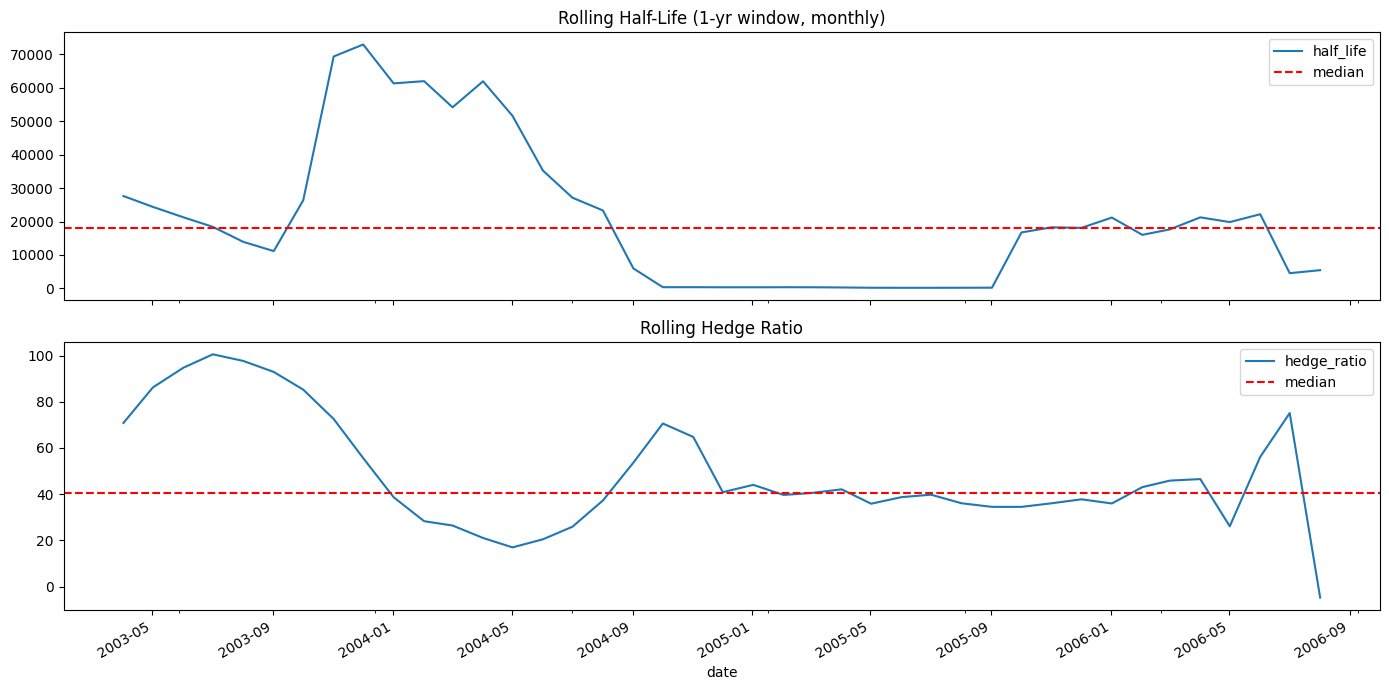

In [24]:
rolling = fx.get_rolling_half_life('EURUSD', 'EURJPY', '1T', file_path)

# Plot both metrics to inspect stability
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
rolling['half_life'].plot(ax=axes[0], title='Rolling Half-Life (1-yr window, monthly)')
axes[0].axhline(rolling['half_life'].median(), color='red', linestyle='--', label='median')
axes[0].legend()
rolling['hedge_ratio'].plot(ax=axes[1], title='Rolling Hedge Ratio')
axes[1].axhline(rolling['hedge_ratio'].median(), color='red', linestyle='--', label='median')
axes[1].legend()
plt.tight_layout()

In [48]:
valid_half_lives = {
    '1T': (5, 4320),    # 3 days - microstructure noise
    '5T': (5, 1440),    # 5 days
    '10T': (5, 720),    # 5 days
    '15T': (5, 480),    # 5 days
    '30T': (3, 480),    # 10 days
    '1H': (3, 240),     # 10 days
    '3H': (3, 120),     # 15 days
    '6H': (3, 80),      # 20 days
    '1D': (3, 60)       # 60 days
}

In [49]:
sample_hr, sample_hl = fx.get_baseline_hedge_ratio_and_half_life('EURUSD', 'EURJPY', '1T', file_path, feature='Close', split_date='2012-12-31')
print(f"Sample Hedge ratio: {sample_hr}")
print(f"Sample half-life up till 2012: {sample_hl}")

Loading data...
Aligning and preprocessing data...
Processing data...
Sample Hedge ratio: 41.828467167110546
Sample half-life up till 2012: 205044.0020209504


Tha half-life is waaaaaaay outside of our viable thresholds!

In [29]:
baseline_hl_df = pd.DataFrame(
        [[{} for _ in fx_pairs] for _ in fx_pairs],
        index=fx_pairs,
        columns=fx_pairs
    )
baseline_hr_df = pd.DataFrame(
        [[{} for _ in fx_pairs] for _ in fx_pairs],
        index=fx_pairs,
        columns=fx_pairs
    )
n = len(significant_combos)
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    hl, hr = fx.get_baseline_hedge_ratio_and_half_life(pair1, pair2, interval, file_path, feature='Close', split_date='2012-12-31')
    baseline_hl_df.at[pair1, pair2][interval] = hl
    baseline_hr_df.at[pair1, pair2][interval] = hr

Processing 1/274: EURUSD-EURJPY at 1T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 2/274: EURUSD-AUDJPY at 1T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 3/274: EURUSD-AUDJPY at 5T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 4/274: EURUSD-AUDJPY at 15T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 5/274: EURUSD-AUDJPY at 30T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 6/274: EURUSD-AUDJPY at 1H
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 7/274: EURGBP-EURJPY at 15T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 8/274: EURGBP-EURJPY at 30T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 9/274: EURGBP-EURJPY at 1H
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 10/274: EURGB

In [30]:
display(baseline_hl_df)

,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,{},{},{},{},{},{},{},{},{'1T': 41.828467167110546},{},{},"{'1T': 40.87048347983012, '5T': 40.87161704623...",{},{}
EURGBP,{},{},{},{},{},{},{},{},"{'15T': -82.84817503747806, '30T': -82.8504235...",{},"{'15T': -0.8296156213203898, '30T': -0.8295947...","{'1T': -19.014749207166663, '5T': -19.01676603...",{},{}
USDJPY,{},{},{},{},{},{},{},{},{},{},"{'15T': 0.007249309039183516, '30T': 0.0072493...",{},{},{}
GBPUSD,{},{},{},{},{},{},"{'15T': 0.30083509797045904, '30T': 0.30083675...",{},{},{},"{'15T': 0.5281270471377993, '30T': 0.528115878...","{'1T': 40.78767201782972, '5T': 40.78977152672...",{},{}
USDCHF,{},{},{},{},{},{},"{'15T': -0.6422095857096591, '30T': -0.6422087...",{},{},{},{'6H': 0.4623400312144178},"{'1T': -10.892521652698743, '5T': -10.89298578...",{},{}
USDCAD,{},{},{},{},{},{},"{'15T': -0.7778338746551301, '30T': -0.7778369...",{},{},{},"{'15T': 0.24989508401552102, '3H': 0.249905132...","{'1T': -32.69821811042892, '5T': -32.696858210...",{},{}
AUDUSD,{},{},"{'15T': -72.73197931245261, '30T': -72.7318037...","{'5T': 0.3511711205591444, '15T': 0.3511764169...","{'5T': -1.3619523384217975, '15T': -1.36196472...","{'5T': -1.1283199213915425, '15T': -1.12832843...",{},{},{},{},{'15T': -0.546564082410591},"{'1T': 29.264088168285358, '5T': 29.2640146435...",{},{}
NZDUSD,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
EURJPY,{'1T': 0.002485801506015159},{'30T': -0.0020058181295694918},{},{},{},{},{},{},{},{},"{'15T': 0.006811846569255863, '30T': 0.0068118...","{'1T': 0.31520617820886665, '5T': 0.3152061506...",{},{}
GBPJPY,{},{},{},{},{},{},{},{},{'1T': 0.4329155709220964},{},"{'15T': 0.0032780546568735238, '30T': 0.003278...","{'1T': 0.12268202151746707, '5T': 0.1226847871...",{},{}


In [50]:
# Count half-lives by category
within_range = 0
out_of_range_positive = 0
negative = 0

for pair1 in baseline_hl_df.index:
    for pair2 in baseline_hl_df.columns:
        cell_dict = baseline_hl_df.at[pair1, pair2]
        if isinstance(cell_dict, dict):
            for interval, hl in cell_dict.items():
                if interval in valid_half_lives:
                    min_hl, max_hl = valid_half_lives[interval]
                    
                    if hl < 0:
                        negative += 1
                    elif min_hl <= hl <= max_hl:
                        within_range += 1
                    else:  # hl > 0 but outside range
                        out_of_range_positive += 1

total = within_range + out_of_range_positive + negative

print(f"Half-life Analysis:")
print(f"{'='*50}")
print(f"Total combinations analyzed: {total}")
print(f"Within valid range: {within_range} ({within_range/total*100:.1f}%)")
print(f"Out of range (positive): {out_of_range_positive} ({out_of_range_positive/total*100:.1f}%)")
print(f"Negative half-lives: {negative} ({negative/total*100:.1f}%)")

Half-life Analysis:
Total combinations analyzed: 274
Within valid range: 33 (12.0%)
Out of range (positive): 138 (50.4%)
Negative half-lives: 103 (37.6%)


In [34]:
with open('./temp/baseline_half_lives.pkl', 'wb') as f:
    pickle.dump(baseline_hl_df, f)
with open('./temp/baseline_hedge_ratios.pkl', 'wb') as f:
    pickle.dump(baseline_hr_df, f)

## Priority for Trading

| Tier | Description | Action |
|------|-------------|--------|
| **TIER_4** | Valid all periods | Highest conviction, trade first |
| **TIER_1** | Pre + post, broke during crisis | Strong candidate, monitor regime |
| **TIER_2** | Post-crisis only | Trade but watch for breakdown |
| **TIER_3** | Pre-crisis only | Trade while recalibrating rolling metrics |
| **REJECT** | Neither period valid | Drop |

In [51]:
periods = {
    'pre_crisis':  (pd.to_datetime('2001-01-01'), pd.to_datetime('2007-12-31')),  # 4-5 years depending on pair
    'crisis':      (pd.to_datetime('2008-01-01'), pd.to_datetime('2009-12-31')),  # 2 years
    'post_crisis': (pd.to_datetime('2010-01-01'), pd.to_datetime('2012-12-31'))   # 3 years
}

pair_tier_results = {}
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, valid_half_lives, max_period_end=pd.to_datetime('2012-12-31'))
    pair_tier = fx.classify_pair(period_analysis)
    pair_tier_results[(pair1, pair2, interval)] = pair_tier

tier_data = []
for (pair1, pair2, interval), tier in pair_tier_results.items():
    tier_data.append({
        'Pair1': pair1,
        'Pair2': pair2,
        'Interval': interval,
        'Tier': tier
    })

tier_df = pd.DataFrame(tier_data)

tier_counts = tier_df['Tier'].value_counts().sort_index()

print("Tier Distribution:")
print("="*50)
tier_pct = (tier_counts / tier_counts.sum() * 100).round(1)
summary_table = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_pct
})
display(summary_table)

Processing 1/274: EURUSD-EURJPY at 1T
Processing 2/274: EURUSD-AUDJPY at 1T
Processing 3/274: EURUSD-AUDJPY at 5T
Processing 4/274: EURUSD-AUDJPY at 15T
Processing 5/274: EURUSD-AUDJPY at 30T
Processing 6/274: EURUSD-AUDJPY at 1H
Processing 7/274: EURGBP-EURJPY at 15T
Processing 8/274: EURGBP-EURJPY at 30T
Processing 9/274: EURGBP-EURJPY at 1H
Processing 10/274: EURGBP-EURCHF at 15T
Processing 11/274: EURGBP-EURCHF at 30T
Processing 12/274: EURGBP-EURCHF at 1H
Processing 13/274: EURGBP-EURCHF at 3H
Processing 14/274: EURGBP-EURCHF at 6H
Processing 15/274: EURGBP-AUDJPY at 1T
Processing 16/274: EURGBP-AUDJPY at 5T
Processing 17/274: EURGBP-AUDJPY at 15T
Processing 18/274: EURGBP-AUDJPY at 30T
Processing 19/274: EURGBP-AUDJPY at 1H
Processing 20/274: USDJPY-EURCHF at 15T
Processing 21/274: USDJPY-EURCHF at 30T
Processing 22/274: USDJPY-EURCHF at 3H
Processing 23/274: USDJPY-EURCHF at 6H
Processing 24/274: GBPUSD-AUDUSD at 15T
Processing 25/274: GBPUSD-AUDUSD at 30T
Processing 26/274: GBP

,Count,Percentage
Tier,,
REJECT,110,40.1
TIER_1,3,1.1
TIER_2,3,1.1
TIER_3,156,56.9
TIER_4,2,0.7


It seems 2012 is too soon for the cointegration relationships b/w the forex pairs to be up and stable. Let's extend the post-crisis window till 2015 and check out the results.

In [52]:
periods = {
    'pre_crisis':  (pd.to_datetime('2001-01-01'), pd.to_datetime('2007-12-31')),  # 4-5 years depending on pair
    'crisis':      (pd.to_datetime('2008-01-01'), pd.to_datetime('2009-12-31')),  # 2 years
    'post_crisis': (pd.to_datetime('2010-01-01'), pd.to_datetime('2015-12-31'))   # 6 years
}

pair_tier_results = {}
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, valid_half_lives, max_period_end=pd.to_datetime('2015-12-31'))
    pair_tier = fx.classify_pair(period_analysis)
    pair_tier_results[(pair1, pair2, interval)] = pair_tier

tier_data = []
for (pair1, pair2, interval), tier in pair_tier_results.items():
    tier_data.append({
        'Pair1': pair1,
        'Pair2': pair2,
        'Interval': interval,
        'Tier': tier
    })

tier_df = pd.DataFrame(tier_data)

tier_counts = tier_df['Tier'].value_counts().sort_index()

print("Tier Distribution:")
print("="*50)
tier_pct = (tier_counts / tier_counts.sum() * 100).round(1)
summary_table = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_pct
})
display(summary_table)

Processing 1/274: EURUSD-EURJPY at 1T
Processing 2/274: EURUSD-AUDJPY at 1T
Processing 3/274: EURUSD-AUDJPY at 5T
Processing 4/274: EURUSD-AUDJPY at 15T
Processing 5/274: EURUSD-AUDJPY at 30T
Processing 6/274: EURUSD-AUDJPY at 1H
Processing 7/274: EURGBP-EURJPY at 15T
Processing 8/274: EURGBP-EURJPY at 30T
Processing 9/274: EURGBP-EURJPY at 1H
Processing 10/274: EURGBP-EURCHF at 15T
Processing 11/274: EURGBP-EURCHF at 30T
Processing 12/274: EURGBP-EURCHF at 1H
Processing 13/274: EURGBP-EURCHF at 3H
Processing 14/274: EURGBP-EURCHF at 6H
Processing 15/274: EURGBP-AUDJPY at 1T
Processing 16/274: EURGBP-AUDJPY at 5T
Processing 17/274: EURGBP-AUDJPY at 15T
Processing 18/274: EURGBP-AUDJPY at 30T
Processing 19/274: EURGBP-AUDJPY at 1H
Processing 20/274: USDJPY-EURCHF at 15T
Processing 21/274: USDJPY-EURCHF at 30T
Processing 22/274: USDJPY-EURCHF at 3H
Processing 23/274: USDJPY-EURCHF at 6H
Processing 24/274: GBPUSD-AUDUSD at 15T
Processing 25/274: GBPUSD-AUDUSD at 30T
Processing 26/274: GBP

,Count,Percentage
Tier,,
REJECT,113,41.2
TIER_3,161,58.8


In [53]:
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    # print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, valid_half_lives, max_period_end=pd.to_datetime('2015-12-31'))
    post = period_analysis.get('post_crisis')
    pre = period_analysis.get('pre_crisis')
    if pre and pre['valid_hl']:  # only look at pre-valid pairs
        print(f"{pair1}-{pair2} @ {interval}: "
              f"pre_hl={pre['half_life']:.0f} "
              f"post_hl={post['half_life']:.0f} "
              f"post_valid={post['valid_hl']} "
              f"bound=({valid_half_lives[interval]})")

EURUSD-AUDJPY @ 30T: pre_hl=4 post_hl=6509 post_valid=False bound=((3, 480))
EURUSD-AUDJPY @ 1H: pre_hl=4 post_hl=3309 post_valid=False bound=((3, 240))
EURGBP-EURCHF @ 3H: pre_hl=117 post_hl=720 post_valid=False bound=((3, 120))
EURGBP-EURCHF @ 6H: pre_hl=59 post_hl=350 post_valid=False bound=((3, 80))
EURGBP-AUDJPY @ 1T: pre_hl=8 post_hl=164452 post_valid=False bound=((5, 4320))
EURGBP-AUDJPY @ 5T: pre_hl=8 post_hl=35008 post_valid=False bound=((5, 1440))
EURGBP-AUDJPY @ 15T: pre_hl=7 post_hl=12133 post_valid=False bound=((5, 480))
EURGBP-AUDJPY @ 30T: pre_hl=7 post_hl=6140 post_valid=False bound=((3, 480))
EURGBP-AUDJPY @ 1H: pre_hl=7 post_hl=3121 post_valid=False bound=((3, 240))
USDJPY-EURCHF @ 3H: pre_hl=120 post_hl=1031 post_valid=False bound=((3, 120))
USDJPY-EURCHF @ 6H: pre_hl=60 post_hl=515 post_valid=False bound=((3, 80))
GBPUSD-EURCHF @ 15T: pre_hl=423 post_hl=21556 post_valid=False bound=((5, 480))
GBPUSD-EURCHF @ 30T: pre_hl=212 post_hl=11058 post_valid=False bound=((3, 

In [54]:
periods = {
    'pre_crisis':  (pd.to_datetime('2001-01-01'), pd.to_datetime('2007-12-31')),  # 4-5 years depending on pair
    'crisis':      (pd.to_datetime('2008-01-01'), pd.to_datetime('2012-12-31')),  # 5 years
    'post_crisis': (pd.to_datetime('2013-01-01'), pd.to_datetime('2015-12-31'))   # 2 years
}

pair_tier_results = {}
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, valid_half_lives, max_period_end=pd.to_datetime('2015-12-31'))
    pair_tier = fx.classify_pair(period_analysis)
    pair_tier_results[(pair1, pair2, interval)] = pair_tier

tier_data = []
for (pair1, pair2, interval), tier in pair_tier_results.items():
    tier_data.append({
        'Pair1': pair1,
        'Pair2': pair2,
        'Interval': interval,
        'Tier': tier
    })

tier_df = pd.DataFrame(tier_data)

tier_counts = tier_df['Tier'].value_counts().sort_index()

print("Tier Distribution:")
print("="*50)
tier_pct = (tier_counts / tier_counts.sum() * 100).round(1)
summary_table = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_pct
})
display(summary_table)

Processing 1/274: EURUSD-EURJPY at 1T


Processing 2/274: EURUSD-AUDJPY at 1T
Processing 3/274: EURUSD-AUDJPY at 5T
Processing 4/274: EURUSD-AUDJPY at 15T
Processing 5/274: EURUSD-AUDJPY at 30T
Processing 6/274: EURUSD-AUDJPY at 1H
Processing 7/274: EURGBP-EURJPY at 15T
Processing 8/274: EURGBP-EURJPY at 30T
Processing 9/274: EURGBP-EURJPY at 1H
Processing 10/274: EURGBP-EURCHF at 15T
Processing 11/274: EURGBP-EURCHF at 30T
Processing 12/274: EURGBP-EURCHF at 1H
Processing 13/274: EURGBP-EURCHF at 3H
Processing 14/274: EURGBP-EURCHF at 6H
Processing 15/274: EURGBP-AUDJPY at 1T
Processing 16/274: EURGBP-AUDJPY at 5T
Processing 17/274: EURGBP-AUDJPY at 15T
Processing 18/274: EURGBP-AUDJPY at 30T
Processing 19/274: EURGBP-AUDJPY at 1H
Processing 20/274: USDJPY-EURCHF at 15T
Processing 21/274: USDJPY-EURCHF at 30T
Processing 22/274: USDJPY-EURCHF at 3H
Processing 23/274: USDJPY-EURCHF at 6H
Processing 24/274: GBPUSD-AUDUSD at 15T
Processing 25/274: GBPUSD-AUDUSD at 30T
Processing 26/274: GBPUSD-AUDUSD at 1H
Processing 27/274: GB

,Count,Percentage
Tier,,
REJECT,111,40.5
TIER_1,7,2.6
TIER_2,2,0.7
TIER_3,154,56.2


In [55]:
# Print the actual post-crisis half-lives for 
# GBPUSD-AUDUSD, AUDUSD-USDCAD specifically
# These are your most economically motivated pairs
# for pair in ['GBPUSD-AUDUSD', 'AUDUSD-USDCAD', 'AUDUSD-GBPUSD']:
#     for interval in intervals:
#         result = get_result(pair, interval)
#         if result:
#             print(f"{pair} @ {interval}: "
#                   f"pre={result['pre_crisis']['half_life']:.0f} "
#                   f"post={result['post_crisis']['half_life']:.0f} "
#                   f"bound={half_life_bounds[interval]}")
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    # print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, valid_half_lives, max_period_end=pd.to_datetime('2015-12-31'))
    post = period_analysis.get('post_crisis')
    pre = period_analysis.get('pre_crisis')
    if pre and pre['valid_hl']:  # only look at pre-valid pairs
        print(f"{pair1}-{pair2} @ {interval}: "
              f"pre_hl={pre['half_life']:.0f} "
              f"post_hl={post['half_life']:.0f} "
              f"post_valid={post['valid_hl']} "
              f"bound=({valid_half_lives[interval]})")

EURUSD-AUDJPY @ 30T: pre_hl=4 post_hl=2423 post_valid=False bound=((3, 480))
EURUSD-AUDJPY @ 1H: pre_hl=4 post_hl=1251 post_valid=False bound=((3, 240))
EURGBP-EURCHF @ 3H: pre_hl=117 post_hl=226 post_valid=False bound=((3, 120))
EURGBP-EURCHF @ 6H: pre_hl=59 post_hl=111 post_valid=False bound=((3, 80))
EURGBP-AUDJPY @ 1T: pre_hl=8 post_hl=64320 post_valid=False bound=((5, 4320))
EURGBP-AUDJPY @ 5T: pre_hl=8 post_hl=13780 post_valid=False bound=((5, 1440))
EURGBP-AUDJPY @ 15T: pre_hl=7 post_hl=4735 post_valid=False bound=((5, 480))
EURGBP-AUDJPY @ 30T: pre_hl=7 post_hl=2378 post_valid=False bound=((3, 480))
EURGBP-AUDJPY @ 1H: pre_hl=7 post_hl=1224 post_valid=False bound=((3, 240))
USDJPY-EURCHF @ 3H: pre_hl=120 post_hl=266 post_valid=False bound=((3, 120))
USDJPY-EURCHF @ 6H: pre_hl=60 post_hl=133 post_valid=False bound=((3, 80))
GBPUSD-EURCHF @ 15T: pre_hl=423 post_hl=13214 post_valid=False bound=((5, 480))
GBPUSD-EURCHF @ 30T: pre_hl=212 post_hl=6607 post_valid=False bound=((3, 480)

In [ ]:
print(tier_df[['Tier']]

    Pair1   Pair2 Interval    Tier
0  EURUSD  EURJPY       1T  REJECT
1  EURUSD  AUDJPY       1T  REJECT
2  EURUSD  AUDJPY       5T  REJECT
3  EURUSD  AUDJPY      15T  REJECT
4  EURUSD  AUDJPY      30T  TIER_3
